# Pandas Basics

## The standard Numpy and Pandas imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the CSV

In [2]:
df = pd.read_csv('origins-game-fair-2025-schedule.csv')

## Examine the Dataframe

In [3]:
df.columns

Index(['Event Name', 'Event Number', 'Event Type', 'Host Names', 'Description',
       'Price', 'Age Range', 'Max Tickets', 'Sold Count', 'Wait Count',
       'Starts', 'Start Date (UTC)', 'Duration (minutes)', 'More Info', 'Room',
       'Space', 'Date Created', 'Date Updated', 'View URI', 'All Events',
       'Collectible Games Badge', 'Media Events', 'Mermbers Only',
       'Tounament of Pieces', 'Game Master (GM)', 'Game Edition',
       'Game Publisher', 'Game Complexity', 'Player Experience',
       'Rules Taught', 'Is your event a tournament?',
       'What style of tournament', 'Tournament Stage/Round', 'Sub-Category',
       'Hosting Company, Group, or Club', 'Game System',
       'Will characters be provided?'],
      dtype='object')

In [4]:
df.dtypes

Event Name                         object
Event Number                        int64
Event Type                         object
Host Names                         object
Description                        object
Price                               int64
Age Range                          object
Max Tickets                         int64
Sold Count                          int64
Wait Count                          int64
Starts                             object
Start Date (UTC)                   object
Duration (minutes)                  int64
More Info                          object
Room                               object
Space                              object
Date Created                       object
Date Updated                       object
View URI                           object
All Events                          int64
Collectible Games Badge             int64
Media Events                        int64
Mermbers Only                       int64
Tounament of Pieces               

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7815 entries, 0 to 7814
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Event Name                       7815 non-null   object
 1   Event Number                     7815 non-null   int64 
 2   Event Type                       7815 non-null   object
 3   Host Names                       7815 non-null   object
 4   Description                      7814 non-null   object
 5   Price                            7815 non-null   int64 
 6   Age Range                        7815 non-null   object
 7   Max Tickets                      7815 non-null   int64 
 8   Sold Count                       7815 non-null   int64 
 9   Wait Count                       7815 non-null   int64 
 10  Starts                           7815 non-null   object
 11  Start Date (UTC)                 7815 non-null   object
 12  Duration (minutes)               7

In [6]:
len(df)  # how many rows

7815

In [7]:
df.index

RangeIndex(start=0, stop=7815, step=1)

## Inspect values within field

In [8]:
df['Event Type'].value_counts()

Event Type
Board Game                      3026
Roleplaying Game                1765
Miniatures Game                  777
Live Action Roleplaying Game     770
Card Game                        499
Social Deduction/Deception       305
Workshop                         275
Seminars and Panels              156
Media Only                        99
Eclectic                          68
Puzzle Games                      32
Entertainment                     25
Classic Games                     18
Name: count, dtype: int64

<Axes: ylabel='count'>

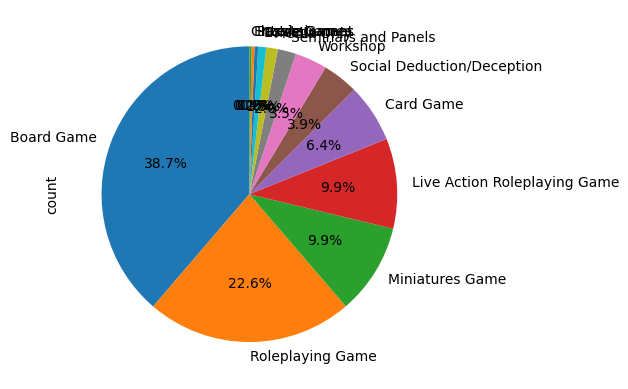

In [9]:
df['Event Type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)

In [10]:
s = df['Event Type'].value_counts().copy(deep=True)
df2 = pd.DataFrame({'Event Type': s}).rename(columns={'Event Type': 'count'})

# data.reset_index(name='count').rename(columns={'index': 'Event Type'})
# data['foo'] = data['Event Type']
# data['angle'] = data['']/data['count'].sum() * 2*pi
print(f"{df2.index=}")
df2

df2.index=Index(['Board Game', 'Roleplaying Game', 'Miniatures Game',
       'Live Action Roleplaying Game', 'Card Game',
       'Social Deduction/Deception', 'Workshop', 'Seminars and Panels',
       'Media Only', 'Eclectic', 'Puzzle Games', 'Entertainment',
       'Classic Games'],
      dtype='object', name='Event Type')


,count
Event Type,
Board Game,3026
Roleplaying Game,1765
Miniatures Game,777
Live Action Roleplaying Game,770
Card Game,499
Social Deduction/Deception,305
Workshop,275
Seminars and Panels,156
Media Only,99


In [11]:
from math import pi

from bokeh.palettes import Category20c

total = df2['count'].sum()
df2['angle'] = df2['count'] / total * 2 * pi
df2['color'] = Category20c[len(df2)]
df2['prct'] = df2['count'] / total * 100
df2

,count,angle,color,prct
Event Type,,,,
Board Game,3026,2.432875,#3182bd,38.720409
Roleplaying Game,1765,1.419043,#6baed6,22.584773
Miniatures Game,777,0.624701,#9ecae1,9.942418
Live Action Roleplaying Game,770,0.619073,#c6dbef,9.852847
Card Game,499,0.401191,#e6550d,6.385157
Social Deduction/Deception,305,0.245217,#fd8d3c,3.902751
Workshop,275,0.221097,#fdae6b,3.518874
Seminars and Panels,156,0.125423,#fdd0a2,1.996161
Media Only,99,0.079595,#31a354,1.266795


In [12]:
from bokeh.plotting import figure, output_notebook, show
from bokeh.io import reset_output
from bokeh.transform import cumsum
from IPython.display import clear_output

clear_output(wait=True)
reset_output()
output_notebook(hide_banner=True)

# df2_for_plot = df2.reset_index().rename(columns={'index': 'Event Type'})

p = figure(height=350, title="Pie Chart", toolbar_location=None,
           tools="hover", tooltips="@{Event Type}: @count (@{prct}%)", x_range=(-0.5, 1.0))

p.wedge(x=0, y=1, radius=0.4,
        start_angle=cumsum('angle', include_zero=True), end_angle=cumsum('angle'),
        line_color="white", fill_color='color', legend_field='Event Type', source=df2)

p.axis.axis_label = None
p.axis.visible = False
p.grid.grid_line_color = None

show(p)


## Narrow down to columns of interest

In [13]:
columns_of_interest = [
    'Event Name', 'Event Number', 'Event Type',
    'Description', 'Price', 'Age Range',
    'Max Tickets', 'Sold Count', 'Wait Count',
    'Start Date (UTC)', 'Duration (minutes)', 'Room',
    'Space', 'Mermbers Only', 'Rules Taught',
    'Will characters be provided?',
]

In [14]:
df[columns_of_interest]

,Event Name,Event Number,Event Type,Description,Price,Age Range,Max Tickets,Sold Count,Wait Count,Start Date (UTC),Duration (minutes),Room,Space,Mermbers Only,Rules Taught,Will characters be provided?
0,Trade Day,9174,Seminars and Panels,Origins Trade Day 2025 is a daylong educationa...,0,Adult (18+),250,152,0,2025-06-18T12:00:00,570,GCCC - 2nd Floor - Meeting Room A 216 - Seminars,Room,1,NaN,NaN
1,End of the Line - 2nd Edition,5855,Board Game,"Line up hoping to collect: food, water, fuel &...",0,Teen Friendly (13+),5,5,2,2025-06-18T16:00:00,120,GCCC - Hall C - 2430 - 6x30 Tables,Table 05,0,Yes,NaN
2,Wayward Spacers - 25 Minute Escape Room,7910,Live Action Roleplaying Game,Adrift in space and supplies are running low –...,22,Teen Friendly (13+),4,0,0,2025-06-18T16:00:00,30,GCCC - 1st Floor - Meeting Room B 132 - Unphazed,Table 01,0,Yes,NaN
3,"Capital City Crimewave, Episode 325",5727,Roleplaying Game,Villains are on the loose in Capital City! The...,0,Teen Friendly (13+),6,6,0,2025-06-18T16:00:00,120,GCCC - 1st Floor - Meeting Room D 180/181 - Pr...,Table 02,0,Yes,Yes
4,Gunfights & Gamblin' Second Edition,3930,Board Game,A gut-punch of a game that pits two to six pla...,0,Teen Friendly (13+),6,6,0,2025-06-18T16:00:00,120,GCCC - Hall C - 2108 - Mid Level Meeple,Table 03 - 6'x30' Rectangle,0,Yes,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7810,Big Dig - 25 Minute Escape Room,7487,Live Action Roleplaying Game,Careful investigation of these ruins will reve...,22,Teen Friendly (13+),4,0,0,2025-06-22T19:30:00,30,GCCC - 1st Floor - Meeting Room B 132 - Unphazed,Table 01,0,Yes,NaN
7811,Build A Foam Sword,5491,Workshop,We are back for yet another amazing year! Come...,14,All Ages (12 and under must be with an adult),20,0,0,2025-06-22T19:30:00,30,GCCC - 2nd Floor - Meeting Room A 220 - Strong...,Table 2,0,NaN,NaN
7812,Sword In The Wall - 25 Minute Escape Room,7810,Live Action Roleplaying Game,Only the worthy may pull the sword out! Maybe ...,22,Teen Friendly (13+),4,0,0,2025-06-22T19:30:00,30,GCCC - 1st Floor - Meeting Room B 132 - Unphazed,Table 04,0,Yes,NaN
7813,Elixir Mixir - 25 Minute Escape Room,7595,Live Action Roleplaying Game,By following the cryptic instructions of a mis...,22,Teen Friendly (13+),4,0,0,2025-06-22T19:30:00,30,GCCC - 1st Floor - Meeting Room B 132 - Unphazed,Table 02,0,Yes,NaN


## Get status for some numeric fields

In [15]:
df[['Price', 'Max Tickets', 'Duration (minutes)']].describe()

,Price,Max Tickets,Duration (minutes)
count,7815.00000,7815.000000,7815.000000
mean,4.84453,10.845425,131.619962
std,10.97069,22.534617,85.677184
min,0.00000,0.000000,30.000000
25%,0.00000,4.000000,60.000000
50%,0.00000,6.000000,120.000000
75%,4.00000,10.000000,180.000000
max,242.00000,360.000000,600.000000


## Convert field with string representation of a UTC date into local datetime

In [16]:
# The original string field
df['Start Date (UTC)']

0       2025-06-18T12:00:00
1       2025-06-18T16:00:00
2       2025-06-18T16:00:00
3       2025-06-18T16:00:00
4       2025-06-18T16:00:00
               ...         
7810    2025-06-22T19:30:00
7811    2025-06-22T19:30:00
7812    2025-06-22T19:30:00
7813    2025-06-22T19:30:00
7814    2025-06-22T19:30:00
Name: Start Date (UTC), Length: 7815, dtype: object

In [17]:
# Convert string to datetime
df['start_date'] = pd.to_datetime(df['Start Date (UTC)'])

In [18]:
# Check the type of the resulting column
df['start_date'].dtypes

dtype('<M8[ns]')

In [19]:
# <M8[ns] is the datetime datatype used by Pandas.  Convert to local time

# This causes a "Cannot convert tz-naive timestamps, use tz_localize to localize"
# apparently my start_date_utc, doesn't have a timezone
#df['start_date_nyc'] = df['start_date_utc'].dt.tz_convert('America/New_York')

# create column with UTC timezone
df['start_date_utc'] = df['start_date'].dt.tz_localize('UTC')

# Now we can create a column with the local time
df['start_date_local'] = df['start_date_utc'].dt.tz_convert('America/New_York')

In [20]:
start_date_fields = ['Start Date (UTC)', 'start_date', 'start_date_utc', 'start_date_local']

# Inspect types of the fields
df[start_date_fields].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7815 entries, 0 to 7814
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype                           
---  ------            --------------  -----                           
 0   Start Date (UTC)  7815 non-null   object                          
 1   start_date        7815 non-null   datetime64[ns]                  
 2   start_date_utc    7815 non-null   datetime64[ns, UTC]             
 3   start_date_local  7815 non-null   datetime64[ns, America/New_York]
dtypes: datetime64[ns, America/New_York](1), datetime64[ns, UTC](1), datetime64[ns](1), object(1)
memory usage: 244.3+ KB


In [21]:
# See what the data looks like
df[start_date_fields].head(5)

,Start Date (UTC),start_date,start_date_utc,start_date_local
0,2025-06-18T12:00:00,2025-06-18 12:00:00,2025-06-18 12:00:00+00:00,2025-06-18 08:00:00-04:00
1,2025-06-18T16:00:00,2025-06-18 16:00:00,2025-06-18 16:00:00+00:00,2025-06-18 12:00:00-04:00
2,2025-06-18T16:00:00,2025-06-18 16:00:00,2025-06-18 16:00:00+00:00,2025-06-18 12:00:00-04:00
3,2025-06-18T16:00:00,2025-06-18 16:00:00,2025-06-18 16:00:00+00:00,2025-06-18 12:00:00-04:00
4,2025-06-18T16:00:00,2025-06-18 16:00:00,2025-06-18 16:00:00+00:00,2025-06-18 12:00:00-04:00


In [22]:
from datetime import datetime
from zoneinfo import ZoneInfo

nyc_timezone = ZoneInfo('America/New_York')

# Events on Sunday the 22nd
df[df['start_date_local'] > datetime(2025, 6, 22, tzinfo=nyc_timezone)]

,Event Name,Event Number,Event Type,Host Names,Description,Price,Age Range,Max Tickets,Sold Count,Wait Count,...,Is your event a tournament?,What style of tournament,Tournament Stage/Round,Sub-Category,"Hosting Company, Group, or Club",Game System,Will characters be provided?,start_date,start_date_utc,start_date_local
7168,Empire Builder: Europe Finals,3299,Board Game,Trella Bromley,Win one Eurorails Qualifying event to advance ...,0,Teen Friendly (13+),24,0,0,...,Yes,Swiss,Final,Train Game,Train Gamers Association,NaN,NaN,2025-06-22 12:00:00,2025-06-22 12:00:00+00:00,2025-06-22 08:00:00-04:00
7169,Press and Media Recording Room- B244,9885,Media Only,Lindsay France,Please schedule for up to two hour blocks of t...,0,All Ages (12 and under must be with an adult),1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-22 12:00:00,2025-06-22 12:00:00+00:00,2025-06-22 08:00:00-04:00
7170,80’s D&D Cartoon Adventures with Level 4 Heroe...,6346,Roleplaying Game,Whoctor,The displaced kids (now young adults) from the...,0,Teen Friendly (13+),6,6,6,...,No,NaN,NaN,Fantasy,NaN,Dungeons and Dragons,Yes,2025-06-22 12:00:00,2025-06-22 12:00:00+00:00,2025-06-22 08:00:00-04:00
7171,Amtgard 101,1789,Live Action Roleplaying Game,Elliott Hedrick,Come learn the basics of foam combat! This wil...,0,Teen Friendly (13+),16,2,0,...,No,NaN,NaN,Fantasy,The Rising Winds,Amtgard,NaN,2025-06-22 12:00:00,2025-06-22 12:00:00+00:00,2025-06-22 08:00:00-04:00
7172,Potion Explosion,264,Board Game,Iejir,"Dear students, It's time for the final exams o...",0,"Kid Friendly (8+, 12 and under must be with an...",8,8,0,...,No,NaN,NaN,Educational,Iejir Works,NaN,NaN,2025-06-22 12:00:00,2025-06-22 12:00:00+00:00,2025-06-22 08:00:00-04:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7810,Big Dig - 25 Minute Escape Room,7487,Live Action Roleplaying Game,Unphazedgames@gmail.com,Careful investigation of these ruins will reve...,22,Teen Friendly (13+),4,0,0,...,No,NaN,NaN,Cooperative,Co-Operatives,Escape Room,NaN,2025-06-22 19:30:00,2025-06-22 19:30:00+00:00,2025-06-22 15:30:00-04:00
7811,Build A Foam Sword,5491,Workshop,Joell,We are back for yet another amazing year! Come...,14,All Ages (12 and under must be with an adult),20,0,0,...,NaN,NaN,NaN,NaN,StrongHold LARP Foam,NaN,NaN,2025-06-22 19:30:00,2025-06-22 19:30:00+00:00,2025-06-22 15:30:00-04:00
7812,Sword In The Wall - 25 Minute Escape Room,7810,Live Action Roleplaying Game,Unphazedgames@gmail.com,Only the worthy may pull the sword out! Maybe ...,22,Teen Friendly (13+),4,0,0,...,No,NaN,NaN,Cooperative,Co-Operatives,Escape Room,NaN,2025-06-22 19:30:00,2025-06-22 19:30:00+00:00,2025-06-22 15:30:00-04:00
7813,Elixir Mixir - 25 Minute Escape Room,7595,Live Action Roleplaying Game,Unphazedgames@gmail.com,By following the cryptic instructions of a mis...,22,Teen Friendly (13+),4,0,0,...,No,NaN,NaN,Cooperative,Co-Operatives,Escape Room,NaN,2025-06-22 19:30:00,2025-06-22 19:30:00+00:00,2025-06-22 15:30:00-04:00


In [23]:
date_mask = df['start_date_local'].between(
    datetime(2025, 6, 21, 12, tzinfo=nyc_timezone),
    datetime(2025, 6, 22, tzinfo=nyc_timezone)
)

filtered = df[
    date_mask &
    (df['Event Type'] == 'Roleplaying Game') &
    (df['Mermbers Only'] == 0) &
    (df['Player Experience'] == 'Beginner') &
    (df['Rules Taught'] == 'Yes')
]

In [24]:
results_fields = [
    'Event Type', 'Game System', 'Game Edition',
    'Event Name', 'Description', 'start_date_local',
    'Duration (minutes)', 'Will characters be provided?',
]
filtered[results_fields]

,Event Type,Game System,Game Edition,Event Name,Description,start_date_local,Duration (minutes),Will characters be provided?
5686,Roleplaying Game,apocalypse,Latest,Wednesday Addams Sequel: Something Woeful This...,The students of Nevermore Academy must use the...,2025-06-21 12:00:00-04:00,240,Yes
5708,Roleplaying Game,Mutants and masterminds,3rd,Legion of Super Heroes: Greased Lightning Saga,"Remember the 50's? The 2950's, when the Legion...",2025-06-21 12:00:00-04:00,240,Yes
5711,Roleplaying Game,NaN,1st,Hell is Full!,A Devil’s Advocate job is to kill THE DAMNED s...,2025-06-21 12:00:00-04:00,180,Yes
5762,Roleplaying Game,The Wildsea,Latest,The Wildsea,Sail across an ocean of trees in chainsaw ship...,2025-06-21 12:00:00-04:00,240,Yes
5774,Roleplaying Game,Xtreem,Latest,Hunt Lucerne,"Through Lucerne Switzerland, become a supernat...",2025-06-21 12:00:00-04:00,240,Yes
...,...,...,...,...,...,...,...,...
7075,Roleplaying Game,Dungeon and dragons,5th,Many Hands Make Short Work: A Kingdom of Kesha...,Limbs due for the Osirian necromantic workshop...,2025-06-21 21:00:00-04:00,240,Yes
7090,Roleplaying Game,Rosebud,2nd,FWS A2503 Mission of Mercy,"Word of a devastating earthquake in Lima, Peru...",2025-06-21 21:00:00-04:00,240,No
7099,Roleplaying Game,Dungeons and Dragons,5th,D&D Learn to Play,"Want to learn to play D&D? New, returning afte...",2025-06-21 21:00:00-04:00,120,Yes
7126,Roleplaying Game,polymorph,Latest,MAZES til Midnight: Burning Parade on the Nigh...,2 hours of a Darkwave soaked crawl across the ...,2025-06-21 22:00:00-04:00,120,Yes


In [25]:
filtered.sort_values('start_date_local')[results_fields]

,Event Type,Game System,Game Edition,Event Name,Description,start_date_local,Duration (minutes),Will characters be provided?
5686,Roleplaying Game,apocalypse,Latest,Wednesday Addams Sequel: Something Woeful This...,The students of Nevermore Academy must use the...,2025-06-21 12:00:00-04:00,240,Yes
5708,Roleplaying Game,Mutants and masterminds,3rd,Legion of Super Heroes: Greased Lightning Saga,"Remember the 50's? The 2950's, when the Legion...",2025-06-21 12:00:00-04:00,240,Yes
5711,Roleplaying Game,NaN,1st,Hell is Full!,A Devil’s Advocate job is to kill THE DAMNED s...,2025-06-21 12:00:00-04:00,180,Yes
5762,Roleplaying Game,The Wildsea,Latest,The Wildsea,Sail across an ocean of trees in chainsaw ship...,2025-06-21 12:00:00-04:00,240,Yes
5774,Roleplaying Game,Xtreem,Latest,Hunt Lucerne,"Through Lucerne Switzerland, become a supernat...",2025-06-21 12:00:00-04:00,240,Yes
...,...,...,...,...,...,...,...,...
7075,Roleplaying Game,Dungeon and dragons,5th,Many Hands Make Short Work: A Kingdom of Kesha...,Limbs due for the Osirian necromantic workshop...,2025-06-21 21:00:00-04:00,240,Yes
7090,Roleplaying Game,Rosebud,2nd,FWS A2503 Mission of Mercy,"Word of a devastating earthquake in Lima, Peru...",2025-06-21 21:00:00-04:00,240,No
7099,Roleplaying Game,Dungeons and Dragons,5th,D&D Learn to Play,"Want to learn to play D&D? New, returning afte...",2025-06-21 21:00:00-04:00,120,Yes
7126,Roleplaying Game,polymorph,Latest,MAZES til Midnight: Burning Parade on the Nigh...,2 hours of a Darkwave soaked crawl across the ...,2025-06-21 22:00:00-04:00,120,Yes


In [26]:
df['Player Experience'].value_counts()

Player Experience
Beginner        6352
Intermediate     818
Expert           121
Name: count, dtype: int64

## Resources

* https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html